## Classificação de risco do câncer de ovário baseada em biomarcadores

### Resumo

O presente trabalho tem como objetivo aplicar técnicas de regressão linear a dados de biomarcadores celulares (CA-125, HE4, CEA, CA 19-9 e AFP) amplamente utilizados na avaliação do risco de câncer de ovário, com o intuito de modelar matematicamente a relação entre os níveis dessas substâncias e o risco oncológico associado. Para cada biomarcador, foi ajustada uma função linear do tipo risco = a·x + b, permitindo quantificar sua contribuição individual na estimativa de risco. A partir dessas funções, desenvolveu-se um modelo computacional capaz de classificar automaticamente pacientes em diferentes categorias de risco (normal, baixo, moderado e alto), considerando a ponderação de cada biomarcador de acordo com sua relevância clínica. Além disso, o trabalho inclui a representação gráfica dos modelos ajustados e dos resultados da classificação, o que facilita a interpretação visual do comportamento dos dados e das decisões geradas pelo sistema.

Ressalta-se que o modelo proposto possui caráter didático, tendo sido desenvolvido com dados simplificados com a finalidade de demonstrar a aplicação prática da regressão linear em problemas biomédicos.

### Código

#### Importação de bibliotecas

As bibliotecas importadas nesta célula fornecem as ferramentas necessárias para todo o projeto:

- **math** — fornece funções matemáticas básicas, como ceil, usada para calcular o número de linhas no grid de gráficos;
- **numpy** — manipula arrays numéricos e realiza operações vetorizadas de forma eficiente;
- **matplotlib** - foi usado para mudar a espessura das hachuras nos gráficos de pizza;
- **matplotlib.pyplot** — cria todos os gráficos (dispersão, linhas, barras e pizza);
- **matplotlib.lines.Line2D / matplotlib.patches.Patch** — personalizam elementos da legenda compartilhada;
- **matplotlib.ticker.FuncFormatter** — formata os valores dos eixos em porcentagem;
- **sklearn.linear_model.LinearRegression** — ajusta os modelos de regressão linear que relacionam nível do biomarcador ao risco previsto.

In [26]:
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression
import sys

In [28]:
print(np.__version__)
print(mpl.__version__)
print(sys.version)

2.2.6
3.10.6
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


#### Dados utilizados

##### Dados de biomarcadores

Cada biomarcador utiliza uma unidade de concentração específica, determinada pela sua natureza bioquímica e pelos métodos laboratoriais padronizados para sua medição:

- **U/mL** (Unidades por mililitro) — usada para proteínas medidas por imunoensaio (CA-125, CA 19-9 e ROMA), onde a "unidade" representa uma quantidade definida por calibração;
- **pmol/L** (picomoles por litro) — usada para HE4, expressando concentração molar em escala muito pequena;
- **ng/mL** (nanogramas por mililitro) — usada para CEA, AFP, Inibina A/B e BRCA1/BRCA2, representando massa de proteína por volume;

As faixas de treino foram calibradas para corresponder, em ordem de grandeza, aos valores de referência clínica mais citados para cada biomarcador (limite superior do normal): CA-125 ≈ 35 U/mL, HE4 ≈ 70 pmol/L (corte pré-menopausa), CEA ≈ 5 ng/mL, CA 19-9 ≈ 37 U/mL, AFP ≈ 10 ng/mL, ROMA ≈ 7,4% (pré-menopausa), Inibina A/B ≈ 5 ng/mL e BRCA1/BRCA2 (marcador de risco genético, limiar simbólico em 0,5 u.a.).

In [11]:
# DADOS (armazenados em dicionário)

biomarcadores = {
    "CA-125": {
        "x": np.array([5, 10, 20, 30, 40, 50, 60, 70]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "U/mL",
    },
    "HE4": {
        "x": np.array([10, 30, 50, 65, 75, 90, 110, 130]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "pmol/L",
    },
    "CEA": {
        "x": np.array([1, 2, 3, 4, 5, 6, 7]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1]),
        "unidade": "ng/mL",
    },
    "CA 19-9": {
        "x": np.array([5, 10, 20, 32, 42, 52, 62, 72]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "U/mL",
    },
    "AFP": {
        "x": np.array([2, 4, 6, 8, 12, 14, 16, 18]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "ng/mL",
    },
    # ROMA: índice calculado combinando CA-125 + HE4 (expresso em %).
    "ROMA": {
        "x": np.array([2.0, 4.0, 6.0, 7.0, 8.0, 10.0, 13.0, 16.0]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "%",
    },
    # Inibina A/B: inibinas são glicoproteínas produzidas pelos ovários.
    "Inibina A/B": {
        "x": np.array([1.0, 2.0, 3.5, 4.5, 6.0, 8.0, 10.0, 12.0]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "ng/mL",
    },
    # BRCA1/BRCA2: representado aqui como escore de expressão relativa (u.a.).
    "BRCA1/BRCA2": {
        "x": np.array([0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]).reshape(-1, 1),
        "y": np.array([0, 0, 0, 0, 1, 1, 1, 1]),
        "unidade": "u.a.",
    },
}

# Os pesos representam a relevância clínica de cada biomarcador.
pesos_biomarcadores = {
    "CA-125":     35,   # maior sensibilidade isolada para câncer de ovário
    "HE4":        25,   # alta especificidade, complementa o CA-125
    "ROMA":       25,   # combina CA-125 + HE4; peso distribuído separadamente
    # Marcadores não tão específicos, pesos mais baixos
    "CEA":         5,   # marcador inespecífico
    "CA 19-9":     5,   # associado a tumores digestivos
    "AFP":         3,   # marcador de tumores de células germinativas
    "Inibina A/B": 1,   # relevante em tumores da granulosa
    "BRCA1/BRCA2": 1,  # risco genético hereditário
    # Proporção entre os pesos é o que importa (mesmo se não somasse 100%).
}

##### Dados de cores para os gráficos

Para manter coerência visual em todos os gráficos, definimos uma paleta centralizada:

- **`CORES_BIOMARCADORES`** — uma cor distinta por biomarcador, usada nos pontos de dispersão, bordas das caixas de equação e fatias da pizza;
- **`COR_ZONA_NORMAL` / `COR_ZONA_RISCO`** — cores de fundo suaves que delimitam as regiões de normalidade (verde) e de risco (vermelha) nos gráficos;
- **`COR_LINHA_MODELO`** — cor da reta de regressão, igual em todos os subgráficos para facilitar a leitura;
- **`COR_PACIENTE`** — cor da estrela que indica a posição do paciente;
- **`COR_RISCO_FORTE` / `COR_NORMAL_FORTE`** — versões saturadas das cores de zona, usadas nas barras e na pizza do resumo do paciente.

In [12]:
# PALETA DE CORES DOS GRÁFICOS 

CORES_BIOMARCADORES = {
    "CA-125":      "#2E86AB",
    "HE4":         "#06A77D",
    "CEA":         "#8E44AD",
    "CA 19-9":     "#E67E22",
    "AFP":         "#C0392B",
    "ROMA":        "#D4AC0D",
    "Inibina A/B": "#1A5276",
    "BRCA1/BRCA2": "#7D3C98",
}
COR_ZONA_NORMAL = "#eafaf1"
COR_ZONA_RISCO = "#fdecea"
COR_LINHA_MODELO = "#1d3557"
COR_PACIENTE = "#f4a300"
COR_RISCO_FORTE = "#e85d75"   # versão saturada da zona de risco, p/ barras e pizza
COR_NORMAL_FORTE = "#7fcdbb"  # versão saturada da zona normal, p/ barras e pizza


#### Funções

Para cada biomarcador, a função `treinar_modelos` aplica regressão linear simples sobre os dados de treinamento (pares de nível do biomarcador × risco associado), obtendo uma reta do tipo **risco = a·x + b**, onde:

- **a** é o coeficiente angular — indica o quanto o risco aumenta a cada unidade do biomarcador;
- **b** é o intercepto — ponto onde a reta cruza o eixo y.

Após o ajuste, calcula-se o coeficiente de determinação **R²**, que mede a qualidade do ajuste: quanto mais próximo de 1, mais a variação do risco é explicada pelo modelo. Os parâmetros extraídos (modelo treinado, a, b e R²) são armazenados em um dicionário.

In [13]:
def treinar_modelos(biomarcadores):
    
    """
    Ajusta uma regressão linear para cada biomarcador. Retorna, para cada biomarcador:
        - modelo  : objeto LinearRegression treinado
        - a       : coeficiente angular (quanto o risco aumenta por unidade)
        - b       : intercepto (valor de risco quando o biomarcador = 0)
        - r2      : R² do ajuste (qualidade do modelo, 0-1)
    """
    
    modelos = {}
    for nome, dados in biomarcadores.items():
        modelo = LinearRegression()
        modelo.fit(dados["x"], dados["y"])
        r2 = modelo.score(dados["x"], dados["y"])
        modelos[nome] = {
            "modelo": modelo,
            "a":      modelo.coef_[0],
            "b":      modelo.intercept_,
            "r2":     r2,
        }
        print(
            f"[{nome}] Função extraída: risco = {modelo.coef_[0]:.4f} * x "
            f"+ {modelo.intercept_:.4f}   (R² = {r2:.3f})"
        )
    return modelos


A função `classificar_paciente` recebe os valores medidos de cada biomarcador e utiliza as funções lineares previamente extraídas para prever, individualmente, o risco associado a cada um.

O fluxo interno é:
1. Para cada biomarcador, calcula-se `risco_previsto = a·x + b`;
2. O resultado é limitado ao intervalo [0, 1] com `np.clip` — a regressão linear pode extrapolar fora desse intervalo para valores muito extremos;
3. O biomarcador é marcado como **em risco** se `risco_previsto ≥ LIMIAR` (0,5 por padrão);
4. Cada previsão é multiplicada pelo peso clínico normalizado do biomarcador, gerando a **contribuição** individual;
5. A soma das contribuições forma o **risco ponderado total** (0 a 1), convertido em uma das quatro categorias: Normal (< 25 %), Baixo risco (25–50 %), Risco moderado (50–75 %) e Alto risco (≥ 75 %).

In [14]:
LIMIAR = 0.5  # a partir desse valor previsto, o biomarcador é considerado "em risco"


def classificar_paciente(modelos, valores_paciente, limiar=LIMIAR, pesos=pesos_biomarcadores):
    """Usa as funções lineares extraídas para prever o risco de cada
    biomarcador, pondera cada previsão pela importância clínica (pesos)
    e combina tudo em uma classificação final.

    Parâmetros
    ----------
    modelos          : dict retornado por treinar_modelos
    valores_paciente : dict {nome_biomarcador: valor_medido}
    limiar           : float — limiar de decisão (padrão 0,5)
    pesos            : dict {nome_biomarcador: peso_clínico}

    Retorna
    -------
    classificacao    : str
    detalhes         : dict com risco_previsto, em_risco, peso, contribuicao
    risco_ponderado  : float (0–1)
    """
    soma_pesos = sum(pesos.values())
    detalhes = {}
    risco_ponderado = 0.0

    for nome, valor in valores_paciente.items():
        info = modelos[nome]
        # np.array evita FeatureWarning em versões recentes do scikit-learn
        risco_previsto = info["modelo"].predict(np.array([[valor]]))[0]
        # Limita a [0, 1] para manter a interpretação como "probabilidade" de risco
        risco_previsto = float(np.clip(risco_previsto, 0, 1))
        em_risco = risco_previsto >= limiar
        peso_normalizado = pesos.get(nome, 0) / soma_pesos
        contribuicao = risco_previsto * peso_normalizado

        detalhes[nome] = {
            "valor":          valor,
            "risco_previsto": risco_previsto,
            "em_risco":       em_risco,
            "peso":           peso_normalizado,
            "contribuicao":   contribuicao,
        }
        risco_ponderado += contribuicao

    if risco_ponderado >= 0.75:
        classificacao = "Alto risco"
    elif risco_ponderado >= 0.50:
        classificacao = "Risco moderado"
    elif risco_ponderado >= 0.25:
        classificacao = "Baixo risco"
    else:
        classificacao = "Normal"

    return classificacao, detalhes, risco_ponderado


A função `plotar_graficos` gera automaticamente um painel de subgráficos organizados em até **três colunas por linha**, adaptando-se à quantidade de biomarcadores sem necessidade de ajuste manual.

Para cada biomarcador, o subgráfico combina:
- Os **pontos de treinamento** (pares nível × risco);
- A **reta de regressão** desenhada sobre 100 pontos interpolados;
- Duas **zonas de fundo coloridas** que delimitam normalidade (verde, abaixo de 50 %) e risco (vermelho, acima de 50 %);
- Quando um paciente é informado, uma **estrela dourada** é plotada na posição exata do seu valor.

A equação extraída (risco = a·x + b) e o R² aparecem em uma caixa no canto superior de cada subgráfico, com borda na cor do biomarcador. Uma **legenda única** é posicionada no rodapé da figura inteira.

In [15]:
def plotar_graficos(biomarcadores, modelos, detalhes_paciente=None, titulo_paciente=""):
    
    """Monta o grid de gráficos automaticamente com base na quantidade de
    biomarcadores (3 colunas por linha). Zonas de fundo verde/vermelha
    indicam a região normal e a região de risco, cada biomarcador tem uma
    cor própria, e há uma única legenda compartilhada no rodapé da figura."""
    
    n = len(biomarcadores)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows), facecolor="#fafafa")
    axs = np.array(axs).reshape(-1)
    # Arrays são estruturas que guardam vários valores juntos em uma única variável, organizados em ordem, permitindo acessar cada um pela sua posição

    for i, (nome, dados) in enumerate(biomarcadores.items()):
        info = modelos[nome]
        modelo = info["modelo"]
        ax = axs[i]
        cor = CORES_BIOMARCADORES.get(nome, "#333333")

        ax.set_facecolor("white")
        ax.axhspan(0, LIMIAR, color=COR_ZONA_NORMAL, zorder=0)
        ax.axhspan(LIMIAR, 1, color=COR_ZONA_RISCO, zorder=0)

        ax.scatter(
            dados["x"], dados["y"], color=cor, s=70, zorder=3,
            edgecolor="white", linewidth=1.2,
        )

        x_linha = np.linspace(dados["x"].min(), dados["x"].max(), 100).reshape(-1, 1)
        ax.plot(
            x_linha, modelo.predict(x_linha),
            color=COR_LINHA_MODELO, linestyle="--", linewidth=2.2, zorder=2,
        )

        if detalhes_paciente is not None:
            d = detalhes_paciente[nome]
            ax.scatter(
                d["valor"], d["risco_previsto"], color=COR_PACIENTE, marker="*",
                s=320, zorder=4, edgecolor="black", linewidth=0.8,
            )

        equacao = f"risco = {info['a']:.3f}x + {info['b']:.3f}\nR² = {info['r2']:.3f}"
        ax.text(
            0.04, 0.95, equacao, transform=ax.transAxes, fontsize=8.5, va="top", color="#333333",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=cor, linewidth=1.1, alpha=0.9),
        )

        ax.set_title(nome, fontsize=13, fontweight="bold", color=cor, pad=10)
        ax.set_xlabel(f"Nível ({dados['unidade']})", fontsize=9.5, color="#555555")
        ax.set_ylabel("Risco previsto", fontsize=9.5, color="#555555")
        ax.set_ylim(-0.05, 1.05)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v * 100)}%"))
        ax.grid(axis="y", color="white", linewidth=1.3, zorder=1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#cccccc")
        ax.spines["bottom"].set_color("#cccccc")
        ax.tick_params(colors="#555555")

    for j in range(n, len(axs)):
        axs[j].axis("off")

    legenda_itens = [
        Line2D([0], [0], marker="o", color="white", markerfacecolor="#888888", markersize=9, label="Dados de treinamento"),
        Line2D([0], [0], color=COR_LINHA_MODELO, linestyle="--", linewidth=2.2, label="Função do modelo (regressão linear)"),
        Patch(facecolor=COR_ZONA_NORMAL, label="Zona normal (risco < 50%)"),
        Patch(facecolor=COR_ZONA_RISCO, label="Zona de risco (risco ≥ 50%)"),
    ]
    if detalhes_paciente is not None:
        legenda_itens.append(
            Line2D([0], [0], marker="*", color="white", markerfacecolor=COR_PACIENTE,
                   markeredgecolor="black", markersize=15, label="Paciente avaliado")
        )

    fig.legend(
        handles=legenda_itens, loc="lower center", ncol=3, frameon=False,
        bbox_to_anchor=(0.5, 0.015), fontsize=10,
    )

    titulo = "Funções Lineares dos Biomarcadores e Classificação de Risco"
    if titulo_paciente:
        titulo += f"\n{titulo_paciente}"
    fig.suptitle(titulo, fontsize=16, fontweight="normal", color="#1d1d1d", y=0.985)

    fig.subplots_adjust(top=0.85, bottom=0.16, hspace=0.4, wspace=0.3)
    plt.show()


A função `plotar_resumo_paciente` gera um painel com **dois gráficos complementares** que sintetizam o resultado da classificação para um paciente específico.

**Gráfico de barras** — exibe o risco previsto de cada biomarcador, ordenado do maior para o menor peso clínico, com as mesmas zonas de fundo verde/vermelha usadas nos demais gráficos.

**Gráfico de pizza** — mostra não uma contagem de 'quantos biomarcadores estão em risco', mas a **contribuição real** de cada biomarcador para o risco ponderado total (risco_previsto × peso normalizado). Isso torna a pizza fiel à lógica interna da classificação: um biomarcador de peso baixo 'em risco' ocupa uma fatia pequena, enquanto um de peso alto concentra a maior parte do risco. Os biomarcadores marcados com ⚠ ultrapassaram o limiar de 50 %.

In [16]:
def plotar_resumo_paciente(detalhes, classificacao):
    
    """Gera barras (risco por biomarcador, ordenado por peso) e pizza
    (contribuição real de cada biomarcador para o risco ponderado total).
    """
    
    nomes        = sorted(detalhes.keys(), key=lambda n: detalhes[n]["peso"], reverse=True)
    riscos       = [detalhes[n]["risco_previsto"] for n in nomes]
    pesos        = [detalhes[n]["peso"]           for n in nomes]
    contribuicoes = [detalhes[n]["contribuicao"]  for n in nomes]
    cores        = [COR_RISCO_FORTE if detalhes[n]["em_risco"] else COR_NORMAL_FORTE for n in nomes]
    risco_ponderado = sum(d["contribuicao"] for d in detalhes.values())

    fig, (ax_bar, ax_pizza) = plt.subplots(1, 2, figsize=(13, 5.5), facecolor="#fafafa")

    # Gráfico de barras ──────────────────────────────────────────────────────────────────────────────────
    ax_bar.set_facecolor("white")
    ax_bar.axhspan(0,      LIMIAR, color=COR_ZONA_NORMAL, zorder=0)
    ax_bar.axhspan(LIMIAR, 1,      color=COR_ZONA_RISCO,  zorder=0)

    barras = ax_bar.bar(nomes, riscos, color=cores, edgecolor="white", linewidth=1.3,
                        width=0.6, zorder=2)
    for barra, risco in zip(barras, riscos):
    
        ax_bar.text(
            barra.get_x() + barra.get_width() / 2, min(risco + 0.05, 1.07),
            f"{risco * 100:.0f}%", ha="center", fontsize=10,
            fontweight="bold", color="#333333", zorder=3,
        )

    ax_bar.set_xticks(range(len(nomes)))
    ax_bar.set_xticklabels(
        [f"{nome}\n(peso {peso * 100:.0f}%)" for nome, peso in zip(nomes, pesos)],
        fontsize=8,
    )
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax_bar.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v * 100)}%"))
    ax_bar.set_ylabel("Risco previsto")
    ax_bar.set_title("Risco por biomarcador\n(ordenado por peso clínico)",
                     fontsize=12, fontweight="bold", color="#1d1d1d")
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.spines["left"].set_color("#cccccc")
    ax_bar.spines["bottom"].set_color("#cccccc")
    ax_bar.grid(axis="y", color="white", linewidth=1.3, zorder=1)

    # Gráfico de pizza ───────────────────────────────────────────────────────────────────────────────────

    PADROES_HACHURA = ['|', '-', '|', '.', '|', '.', '-', '.']

    if risco_ponderado > 0.005:
        cores_pizza  = [CORES_BIOMARCADORES.get(n, "#999999") for n in nomes]
        labels_pizza = [f"{n}{' ⚠' if detalhes[n]['em_risco'] else ''}" for n in nomes]

        padroes_hachura = [PADROES_HACHURA[i % len(PADROES_HACHURA)] for i in range(len(nomes))]

        mpl.rcParams['hatch.linewidth'] = 0.2
        
        wedges, texts, autotexts = ax_pizza.pie(
            contribuicoes, labels=labels_pizza, colors=cores_pizza, startangle=90,
            autopct=lambda p: f"{p:.0f}%" if p >= 3 else "",
            pctdistance=0.75,
            wedgeprops=dict(edgecolor="white", linewidth=1.5),
        )

        for wedge, hatch in zip(wedges, padroes_hachura):
            wedge.set_hatch(hatch)
            wedge.set_edgecolor("white")   # borda branca entre as hachuras
            wedge.set_linewidth(0.8)       # deixa a borda mais fina e legível
        
        ax_pizza.set_title(
            f"Participação no risco ponderado total\n({risco_ponderado * 100:.1f}%)",
            fontsize=12, fontweight="bold", color="#1d1d1d",
        )
        
    else:
        ax_pizza.text(0.5, 0.5, "Risco ponderado ≈ 0%",
                      ha="center", va="center", fontsize=12, color="#555555")
        ax_pizza.set_title("Participação no risco ponderado total",
                           fontsize=12, fontweight="bold", color="#1d1d1d")
        ax_pizza.axis("off")
    fig.suptitle(f"Resumo do paciente — Classificação final: {classificacao}",
                 fontsize=15, fontweight="normal", color="#1d1d1d")
    fig.text(0.5, 0.01, "⚠ = biomarcador acima do limiar de risco (50%)",
             ha="center", fontsize=8.5, color="#777777")
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

#### Execução - avaliando pacientes

O bloco a seguir é o ponto de entrada do programa. Ele:

1. **Treina todos os modelos** chamando `treinar_modelos`, que imprime as equações e os R² de cada biomarcador;
2. **Avalia dois perfis de paciente** distintos por meio de uma função auxiliar `avaliar_paciente`, que centraliza a lógica de impressão e plotagem, evitando repetição de código:
   - **Paciente 1** — valores próximos ao limite superior da normalidade clínica (caso de fronteira);
   - **Paciente 2** — valores claramente elevados em todos os marcadores (perfil de alto risco).

Para cada paciente são gerados dois conjuntos de gráficos: o painel com as funções lineares (`plotar_graficos`) e o resumo com barras e pizza (`plotar_resumo_paciente`).

[CA-125] Função extraída: risco = 0.0200 * x + -0.2131   (R² = 0.776)
[HE4] Função extraída: risco = 0.0111 * x + -0.2778   (R² = 0.694)
[CEA] Função extraída: risco = 0.2143 * x + -0.4286   (R² = 0.750)
[CA 19-9] Função extraída: risco = 0.0193 * x + -0.2124   (R² = 0.778)
[AFP] Função extraída: risco = 0.0833 * x + -0.3333   (R² = 0.833)
[ROMA] Função extraída: risco = 0.0936 * x + -0.2726   (R² = 0.656)
[Inibina A/B] Função extraída: risco = 0.1186 * x + -0.1969   (R² = 0.741)
[BRCA1/BRCA2] Função extraída: risco = 1.6667 * x + -0.3333   (R² = 0.833)

=== Paciente com valores ideais ===
  CA-125: valor=35 -> risco previsto=0.487 (normal)
  HE4: valor=70 -> risco previsto=0.500 (EM RISCO)
  CEA: valor=4 -> risco previsto=0.429 (normal)
  CA 19-9: valor=37 -> risco previsto=0.502 (EM RISCO)
  AFP: valor=10 -> risco previsto=0.500 (EM RISCO)
  ROMA: valor=7.0 -> risco previsto=0.383 (normal)
  Inibina A/B: valor=4.5 -> risco previsto=0.337 (normal)
  BRCA1/BRCA2: valor=0.4 -> risco pre

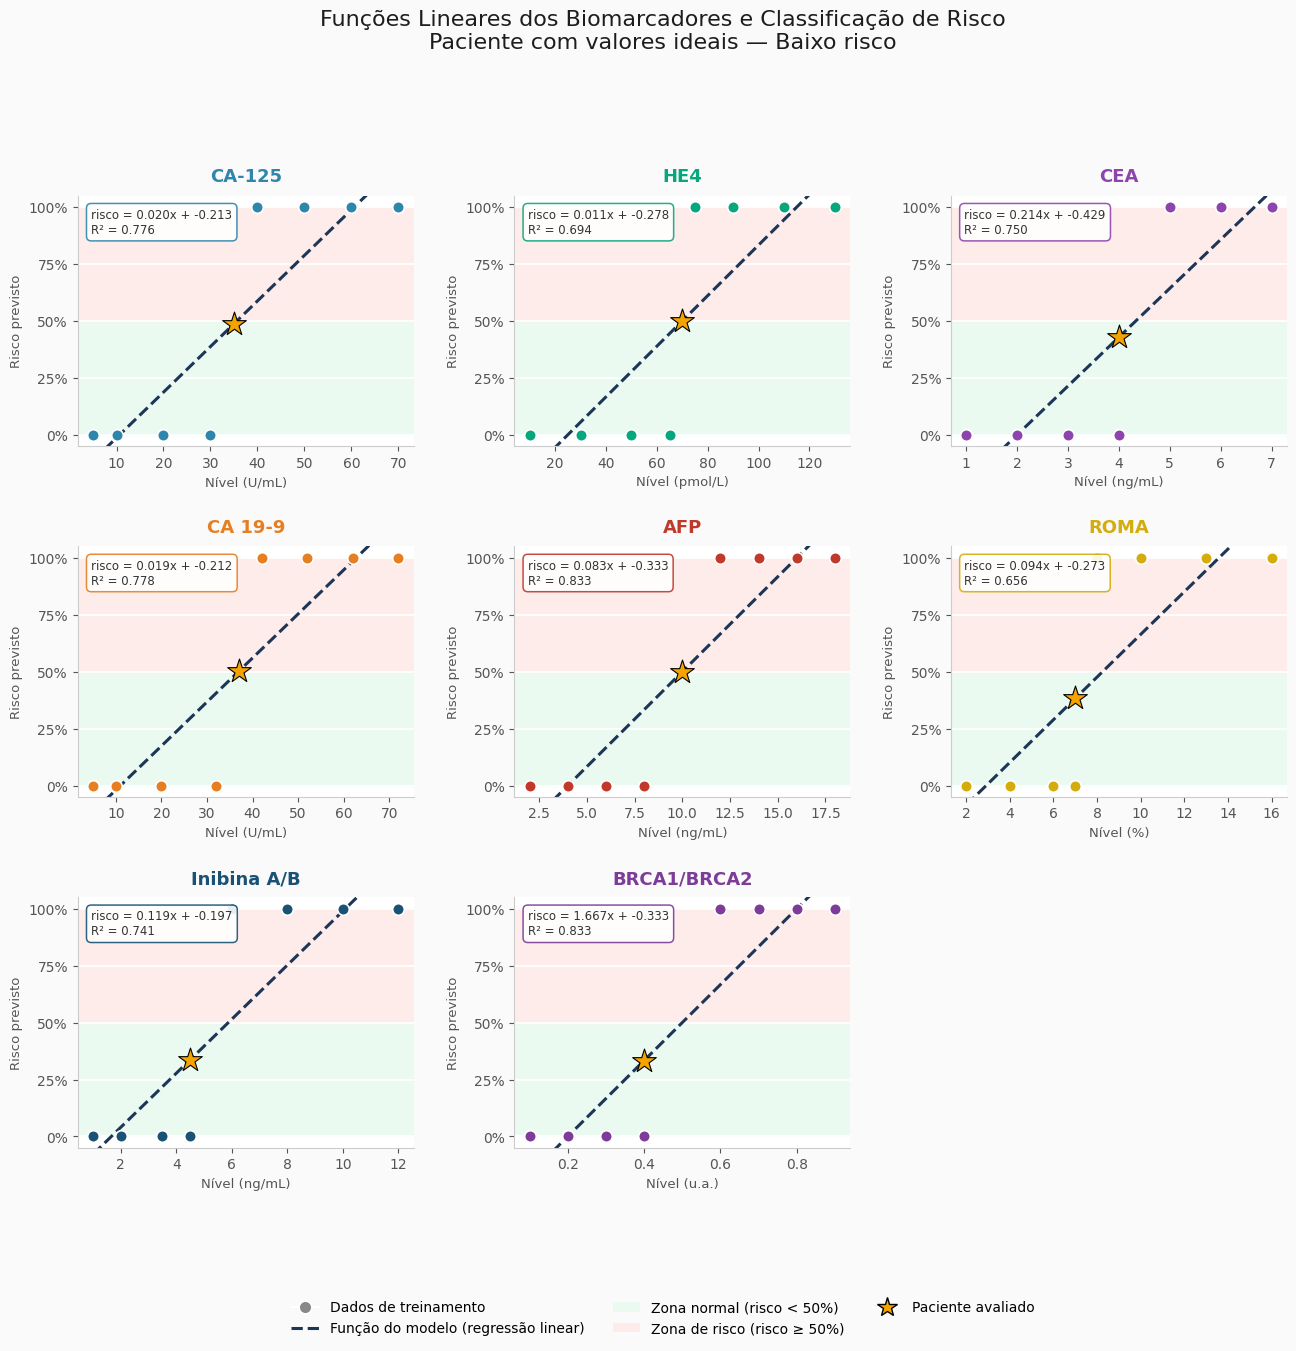

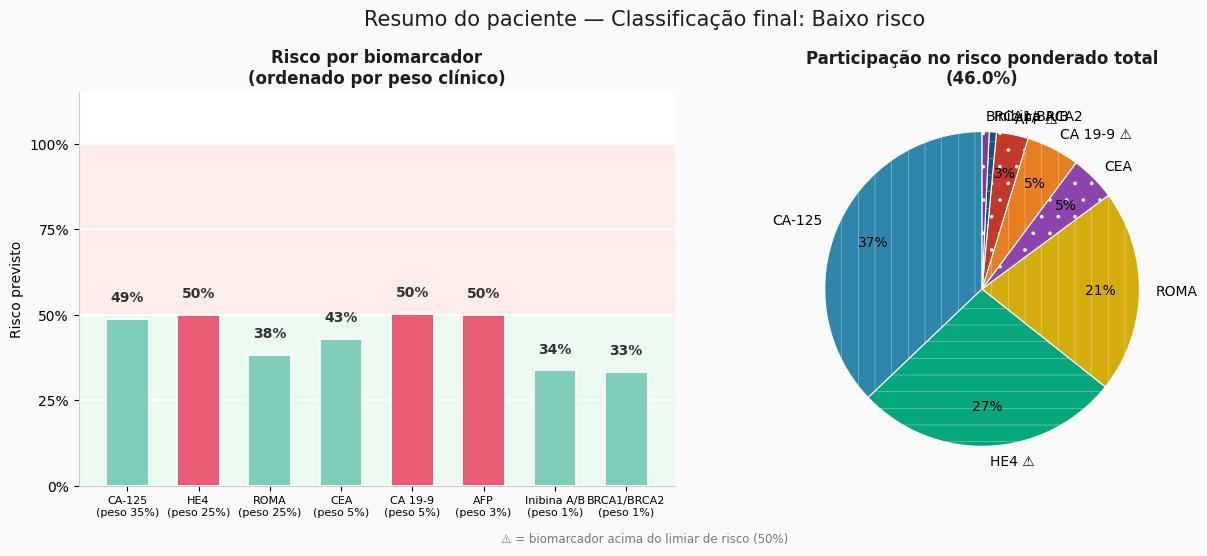


=== Paciente com valores suspeitos ===
  CA-125: valor=120 -> risco previsto=1.000 (EM RISCO)
  HE4: valor=150 -> risco previsto=1.000 (EM RISCO)
  CEA: valor=12 -> risco previsto=1.000 (EM RISCO)
  CA 19-9: valor=90 -> risco previsto=1.000 (EM RISCO)
  AFP: valor=35 -> risco previsto=1.000 (EM RISCO)
  ROMA: valor=20.0 -> risco previsto=1.000 (EM RISCO)
  Inibina A/B: valor=15.0 -> risco previsto=1.000 (EM RISCO)
  BRCA1/BRCA2: valor=0.9 -> risco previsto=1.000 (EM RISCO)

Risco ponderado total: 1.000
Classificação final: Alto risco


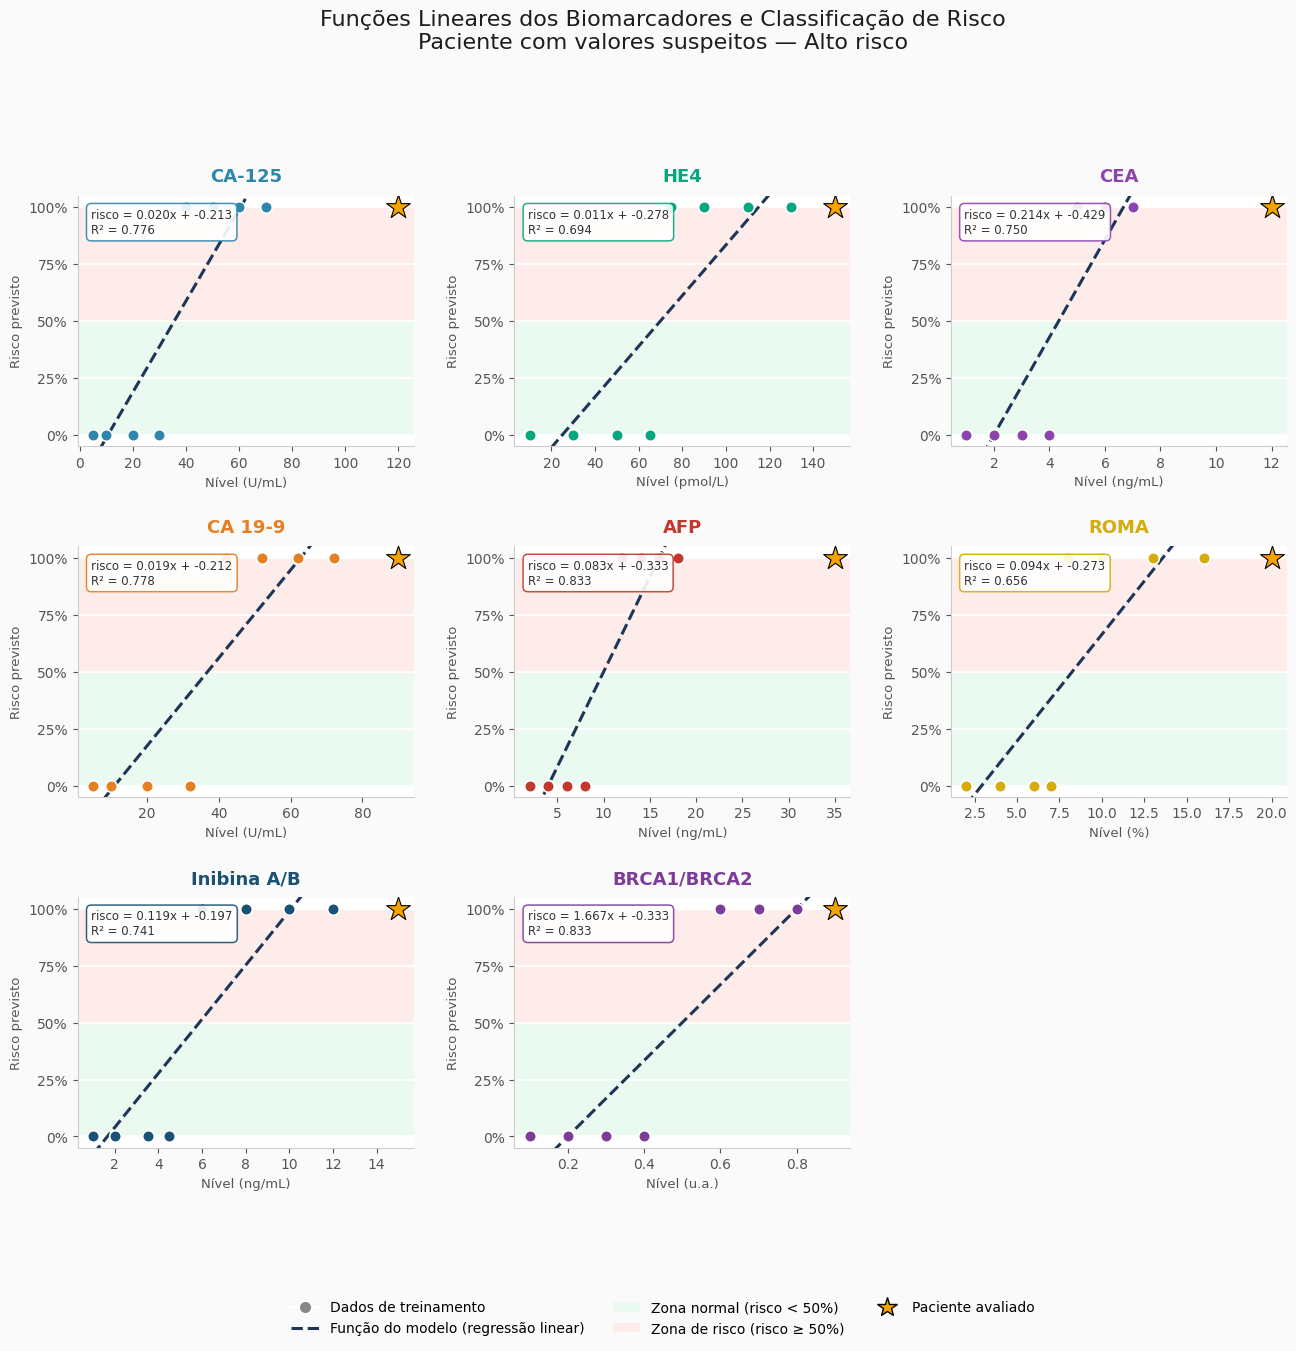

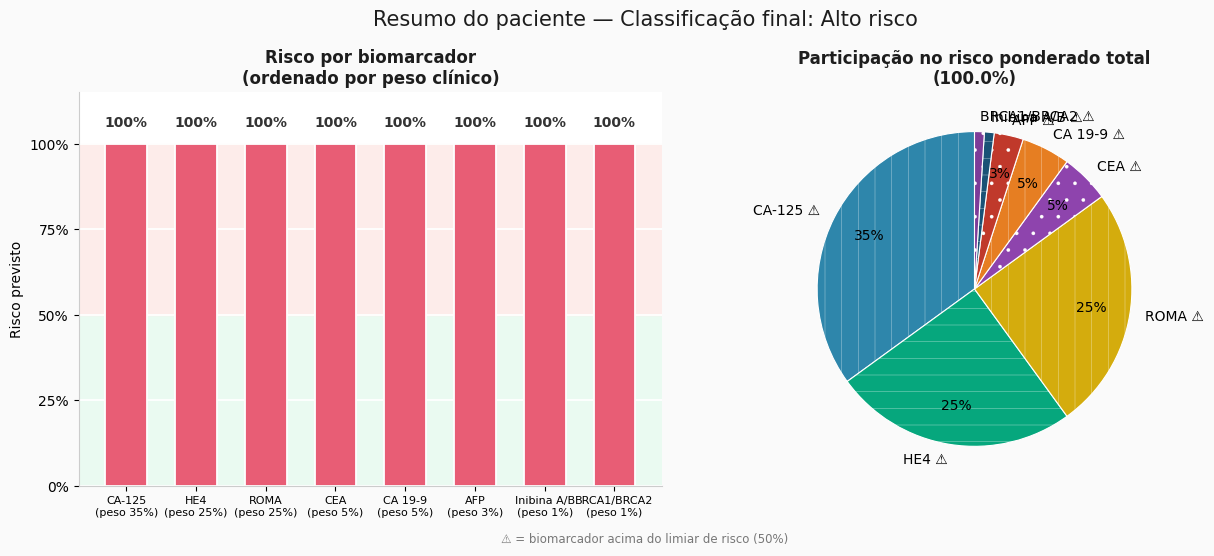

In [17]:
def avaliar_paciente(titulo, valores, modelos):
    
    """Avalia um paciente, imprime o resultado e gera os gráficos."""
    
    print(f"\n=== {titulo} ===")
    classificacao, detalhes, risco_ponderado = classificar_paciente(modelos, valores)
    for nome, info in detalhes.items():
        status = "EM RISCO" if info["em_risco"] else "normal"
        print(f"  {nome}: valor={info['valor']} -> risco previsto={info['risco_previsto']:.3f} ({status})")
    print(f"\nRisco ponderado total: {risco_ponderado:.3f}")
    print(f"Classificação final: {classificacao}")
    plotar_graficos(
        biomarcadores, modelos,
        detalhes_paciente=detalhes,
        titulo_paciente=f"{titulo} — {classificacao}",
    )
    plotar_resumo_paciente(detalhes, classificacao)


if __name__ == "__main__":
    modelos = treinar_modelos(biomarcadores)

    # ── Paciente 1: valores próximos ao limite superior da normalidade ────────
    avaliar_paciente(
        titulo="Paciente com valores ideais",
        valores={
            "CA-125":      35,
            "HE4":         70,
            "CEA":          4,
            "CA 19-9":     37,
            "AFP":         10,
            "ROMA":         7.0,
            "Inibina A/B":  4.5,
            "BRCA1/BRCA2":  0.4,
        },
        modelos=modelos,
    )

    # ── Paciente 2: valores suspeitos (alterados em todos os biomarcadores) ───
    avaliar_paciente(
        titulo="Paciente com valores suspeitos",
        valores={
            "CA-125":      120,
            "HE4":         150,
            "CEA":          12,
            "CA 19-9":      90,
            "AFP":          35,
            "ROMA":         20.0,
            "Inibina A/B":  15.0,
            "BRCA1/BRCA2":   0.9,
        },
        modelos=modelos,
    )


### Conclusão

O presente trabalho demonstrou que a regressão linear pode ser aplicada de forma eficaz na modelagem da relação entre níveis de biomarcadores e risco oncológico, ainda que em um contexto simplificado e de caráter didático. A partir do ajuste de funções lineares para oito biomarcadores (CA-125, HE4, CEA, CA 19-9, AFP, ROMA, Inibina A/B e BRCA1/BRCA2) foi possível construir um sistema automatizado de classificação de risco capaz de categorizar pacientes em níveis distintos (normal, baixo, moderado e alto), ponderando a contribuição de cada marcador de acordo com sua relevância clínica estabelecida. Os testes realizados com dois perfis de pacientes ilustraram o comportamento do modelo em cenários opostos: um paciente com valores dentro ou próximos à normalidade, classificado sem biomarcadores em grande risco, e outro com valores acentuadamente elevados em todos os marcadores, resultando em classificação de alto risco. A representação gráfica dos modelos ajustados e dos resumos por paciente, incluindo recursos de acessibilidade visual para daltônicos por meio de hachuras diferenciadas, contribuiu para tornar os resultados interpretáveis de forma clara e inclusiva. Conclui-se que a integração entre modelagem matemática e visualização de dados constitui uma abordagem promissora para o suporte à triagem oncológica.

### Referências

VILLELA-CASTREJON, Javier; LEVINE, Herbert; KAIPPARETTU, Benny A.; ONUCHIC, José N.; GEORGE, Jason T.; JIA, Dongya. "Computational modeling of cancer cell metabolism along the catabolic-anabolic axes", npj Systems Biology and Applications. Pubicado 10 maio 2025. Disponível em: https://www.nature.com/articles/s41540-025-00525-x. Acesso em: 13 maio 2026

CBIOPORTAL FOR CANCER GENOMICS. Atualizado em: 10 de abril 2026. Disponível em: https://www.cbioportal.org/ . Acesso em: 20 maio 2026.

GTEX PORTAL. Disponível em: <https://www.gtexportal.org/home/>. Acesso em: 20 maio 2026.

MATPLOTLIB. Pyplot tutorial. Disponível em: <https://br.matplotlib.net/stable/tutorials/introductory/pyplot.html>. Acesso em: 4 jun. 2026.

NUMPY. Disponível em: <https://numpy.org/>. Acesso em: 4 jun. 2026.

AZIZI, Tahmineh. Mathematical modeling of cancer progression. Públicado 2 setembro 2024. Disponível em: <https://doi.org/10.3390/appliedmath4030057>. Acesso em: 4 jun. 2026. 

NATIONAL COMPREHENSIVE CANCER NETWORK (NCCN). Disponível em: <https://www.nccn.org/>. Acesso em: 17 jun. 2026

MICROSOFT. Copilot (modelo GPT-5). Orientações sobre uso de cores (HEX, RGB, nomes) e propriedades de fonte (fontweight) em gráficos no Python (matplotlib). Acesso em: 6 jun. 2026.

Claude (versão Sonnet 4.6). Plataforma de inteligência artificial generativa. Orientação de melhorias para notebook Python. Resposta gerada em: 19  jun 2026. Disponível em: https://claude.ai. Acesso em: 19 jun. 2026.

SCIKIT-LEARN. Supervised learning. Disponível em: https://scikit-learn.org/stable/supervised_learning.html. Acesso em: 6 jun. 2026.